In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Set visual style
sns.set_theme(style="whitegrid", palette="pastel")

In [10]:
# Load Data
df_urls = pd.read_csv("C:/Users/Kyliv/Projects/Data_Science_Project/Data/urls/game_highlight_urls.csv")
print("Highlights Data:")
display(df_urls.head())

df_games = pd.read_csv("C:/Users/Kyliv/Projects/Data_Science_Project/Data/exposure_and_game_info/nba_games_2025-26.csv")
print("Games Data:")
display(df_games.head())

Highlights Data:


,game_id,title,url,video_id,channel,duration,view_count,like_count,comment_count
0,22500431,Los Angeles Clippers vs Portland Trail Blazers...,https://www.youtube.com/watch?v=11LdwX87xkY,11LdwX87xkY,GAMETIME HIGHLIGHTS,587,99233,1011,64.0
1,22500409,Charlotte Hornets vs Washington Wizards Full G...,https://www.youtube.com/watch?v=IrpfL0OcIuI,IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0
2,22500424,Charlotte Hornets vs Orlando Magic Full Game H...,https://www.youtube.com/watch?v=l5ir1TZxJjk,l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0
3,22500430,Detroit Pistons vs Utah Jazz Full Game Highlig...,https://www.youtube.com/watch?v=U5T9X6OK6OA,U5T9X6OK6OA,GAMETIME HIGHLIGHTS,586,62175,658,38.0
4,22500413,Milwaukee Bucks vs Indiana Pacers Full Game Hi...,https://www.youtube.com/watch?v=liAwHhl5zPk,liAwHhl5zPk,GAMETIME HIGHLIGHTS,589,22880,283,31.0


Games Data:


,HOME_TEAM_ID,HOME_TEAM_ABBREVIATION,HOME_TEAM_NAME,GAME_ID,GAME_DATE,MIN,HOME_PTS,HOME_FGM,HOME_FGA,HOME_FG_PCT,HOME_FG3M,HOME_FG3A,HOME_FG3_PCT,HOME_FTM,HOME_FTA,HOME_FT_PCT,HOME_OREB,HOME_DREB,HOME_REB,HOME_AST,HOME_STL,HOME_BLK,HOME_TOV,HOME_PF,HOME_PLUS_MINUS,AWAY_TEAM_ID,AWAY_TEAM_ABBREVIATION,AWAY_TEAM_NAME,AWAY_PTS,AWAY_FGM,AWAY_FGA,AWAY_FG_PCT,AWAY_FG3M,AWAY_FG3A,AWAY_FG3_PCT,AWAY_FTM,AWAY_FTA,AWAY_FT_PCT,AWAY_OREB,AWAY_DREB,AWAY_REB,AWAY_AST,AWAY_STL,AWAY_BLK,AWAY_TOV,AWAY_PF,AWAY_PLUS_MINUS
0,1610612753,ORL,Orlando Magic,22500424,2025-12-26,239,105,37,93,0.398,11,35,0.314,20,23,0.870,16,26,42,22,7,7,9,25,-15.0,1610612766,CHA,Charlotte Hornets,120,41,87,0.471,19,39,0.487,19,28,0.679,16,37,53,23,3,6,14,19,15.0
1,1610612764,WAS,Washington Wizards,22500425,2025-12-26,242,138,54,91,0.593,15,33,0.455,15,18,0.833,6,40,46,26,8,7,13,23,21.0,1610612761,TOR,Toronto Raptors,117,40,91,0.440,12,36,0.333,25,27,0.926,8,25,33,26,10,5,11,16,-21.0
2,1610612737,ATL,Atlanta Hawks,22500423,2025-12-26,241,111,40,85,0.471,12,36,0.333,19,21,0.905,5,37,42,26,6,5,21,16,-15.0,1610612748,MIA,Miami Heat,126,49,104,0.471,11,36,0.306,17,18,0.944,13,39,52,29,14,2,10,16,15.0
3,1610612740,NOP,New Orleans Pelicans,22500429,2025-12-26,240,108,39,88,0.443,5,25,0.200,25,42,0.595,12,26,38,22,10,2,12,22,-7.0,1610612756,PHX,Phoenix Suns,115,44,91,0.484,8,40,0.200,19,25,0.760,16,36,52,26,9,4,17,27,7.0
4,1610612754,IND,Indiana Pacers,22500426,2025-12-26,240,122,44,89,0.494,18,44,0.409,16,20,0.800,11,24,35,29,6,3,14,28,-18.0,1610612738,BOS,Boston Celtics,140,47,83,0.566,20,39,0.513,26,34,0.765,12,31,43,26,8,3,12,22,18.0


In [11]:
# How many games are covered?
print(f"Number of games: {df_urls['game_id'].nunique()}")

# How many videos in total?
print(f"Number of videos: {df_urls['video_id'].nunique()}")

# Average videos per game
avg_videos = df_urls['video_id'].nunique() / df_urls['game_id'].nunique()
print(f"Average urls per game: {avg_videos:.2f}")

Number of games: 454
Number of videos: 1497
Average urls per game: 3.30


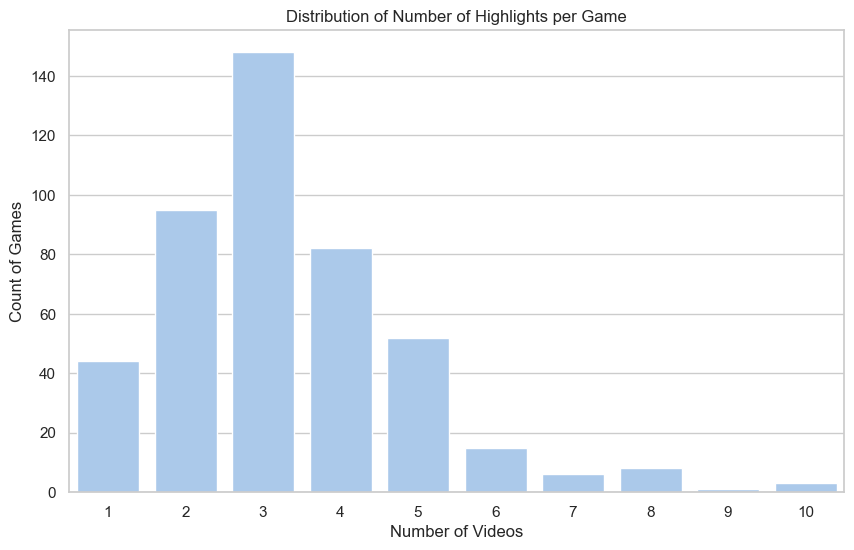

In [12]:
# Distribution of number of urls per game
nb_urls_per_game = df_urls.groupby('game_id')['video_id'].count()
df_urls['nb_urls_per_game'] = df_urls['game_id'].map(nb_urls_per_game)

plt.figure(figsize=(10, 6))
sns.countplot(x=nb_urls_per_game)
plt.title("Distribution of Number of Highlights per Game")
plt.xlabel("Number of Videos")
plt.ylabel("Count of Games")
plt.show()

We clearly observe that some games have more videos on YouTube. This probably depends on the importance or popularity of a game, but other factors also play a role, such as when the code was run, as explained just after.

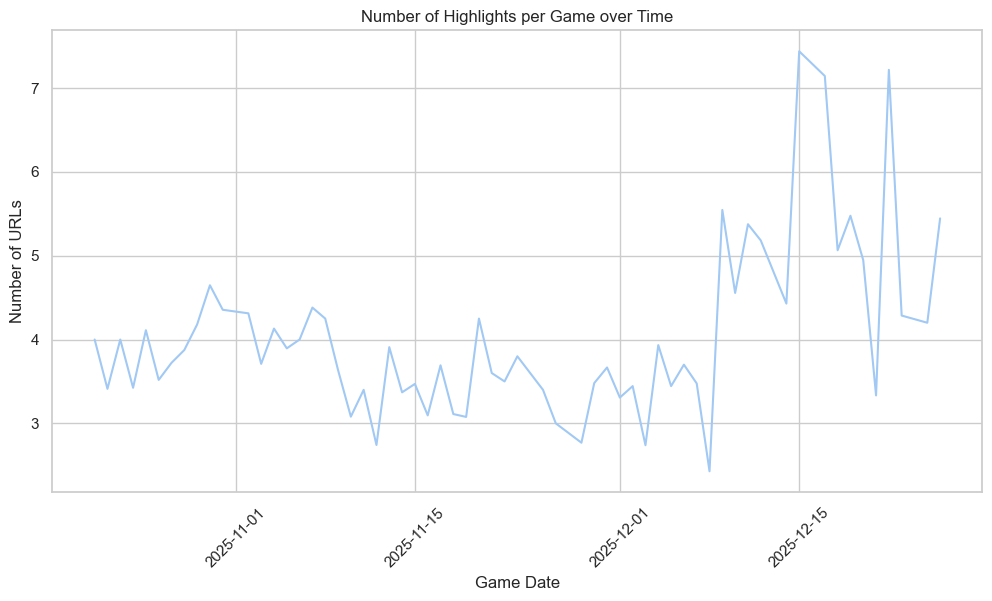

In [14]:
# Let's check if it depends on the date of video (maybe some video get banned on yt)

# Merge with game data to get dates
df_merge = pd.merge(df_urls, df_games[['GAME_ID', 'GAME_DATE']], left_on='game_id', right_on='GAME_ID').drop(columns='GAME_ID')

# Convert to datetime for proper sorting/plotting
df_merge['GAME_DATE'] = pd.to_datetime(df_merge['GAME_DATE'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='GAME_DATE', y='nb_urls_per_game', data=df_merge, errorbar=None)
plt.title("Number of Highlights per Game over Time")
plt.xticks(rotation=45)
plt.xlabel("Game Date")
plt.ylabel("Number of URLs")
plt.show()

As expected, we find more games when a game is new than when it is older. This is a problem because it creates a bias and gives more importance to new games. This issue can be solved by running the code once a week, for example, to update the database with new games each time, rather than running it only once as done here.

Several reasons can explain this. First, some videos may get banned. Another hypothesis, which I believe is more likely, is that since we use a YouTube search to find the videos, older videos are probably not recommended by YouTube in the first 10 results we are considering.

We then ask the following question: is this really a problem, given that our goal is to predict future exposure and that the main component of this exposure is the number of views? Indeed, having more videos does not necessarily mean more views in the end, because only one or two videos may concentrate 90% of the views. Alternatively, having more videos might dilute the number of views, as people are unlikely to watch similar videos multiple times. However, this needs to be verified, since having more videos also increases the chances of coming across the game on YouTube, which could lead to additional views that are independent of the game’s intrinsic characteristics.

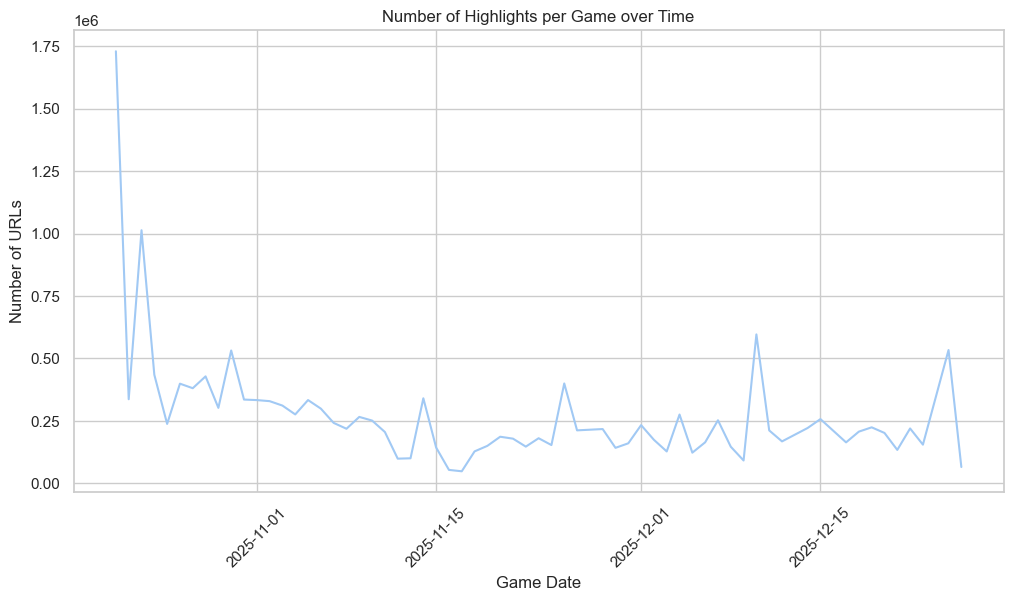

In [24]:
# Let's check if the view depend on the date of video

view_per_game = df_merge.groupby('game_id').agg({
    'view_count': 'sum',
    'GAME_DATE': 'first'
})

plt.figure(figsize=(12, 6))
sns.lineplot(x='GAME_DATE', y='view_count', data=view_per_game, errorbar=None)
plt.title("Number of Highlights per Game over Time")
plt.xticks(rotation=45)
plt.xlabel("Game Date")
plt.ylabel("Number of URLs")
plt.show()

We do not seem to observe more views for newer videos, despite the number of links found on YouTube. However, we do notice a peak at the beginning of the season, which corresponds to the start of the NBA season. For NBA fans, this is a very important moment, as they spend about four months without watching any games.

Note: We exclude very recent games (from the past 7 days) to avoid issues related to the “potential” of a video. Indeed, without this restriction, we would include very new videos (only a few hours old), and their number of views would be biased by their short exposure time. Seven days is probably a reasonable threshold, since each team plays 3 or 4 games per week (with 30 teams, this results in many games each week), and there is generally little interest in revisiting regular-season games after the following week. While some people might still do so, we can confidently say that after a week (and probably even a bit less), a regular-season game has reached its full “view potential.”

--- view_count Statistics ---
count    1.501000e+03
mean     7.284791e+04
std      1.513889e+05
min      1.000000e+03
25%      3.186000e+03
50%      1.374600e+04
75%      7.504000e+04
max      2.034788e+06
Name: view_count, dtype: float64


--- like_count Statistics ---
count     1501.000000
mean       836.379081
std       1608.020848
min          2.000000
25%         71.000000
50%        190.000000
75%        872.000000
max      20083.000000
Name: like_count, dtype: float64


--- comment_count Statistics ---
count    1333.000000
mean       73.659415
std       144.065408
min         1.000000
25%         4.000000
50%        17.000000
75%        73.000000
max      1400.000000
Name: comment_count, dtype: float64




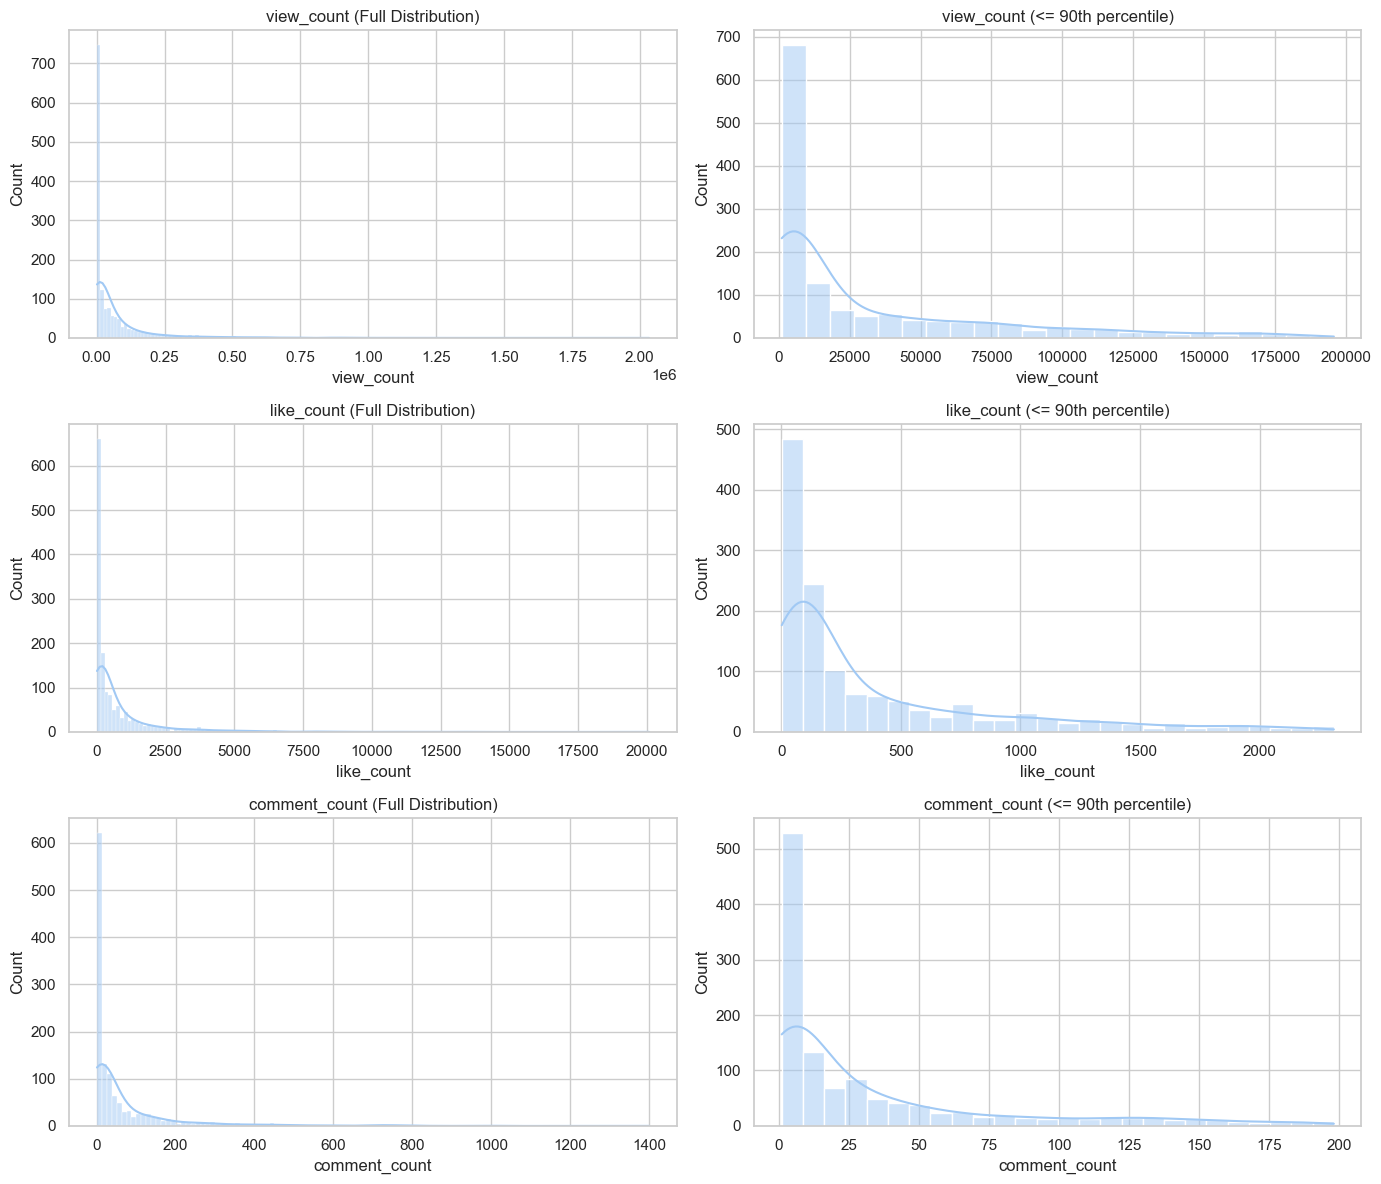

In [27]:
# Columns to analyze
cols = ['view_count', 'like_count', 'comment_count']

# Calculate 90th percentiles to zoom in on the bulk of the data
q90 = {col: df_merge[col].quantile(0.90) for col in cols}

# Create subplots: 3 rows × 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

for i, col in enumerate(cols):
    # 1. Full Histogram (Log scale might be better visually, but keeping linear as per original intent)
    sns.histplot(df_merge[col], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"{col} (Full Distribution)")
    
    # 2. Truncated Histogram (<= 90th percentile) for better detail
    sns.histplot(df_merge[df_merge[col] <= q90[col]][col], ax=axes[i, 1], kde=True)
    axes[i, 1].set_title(f"{col} (<= 90th percentile)")

    # Print stats
    print(f"--- {col} Statistics ---")
    print(df_merge[col].describe())
    print("\n")

plt.tight_layout()
plt.show()

We can see that most videos are not very popular, which is expected. There are a few very large YouTube channels that post game videos very quickly and attract most of the views. These popular videos are usually the ones that appear first in YouTube search results and are therefore watched by the majority of viewers.

In [ ]:
# Inspection of videos with 0 views
zero_views = df_merge[df_merge['view_count'] == 0]
print(f"Sample of videos with 0 views:\n{zero_views['url'].head(5)}")

print(f"Number of videos without views: {zero_views.shape[0]}")
print(f"Percentage of videos without views: {zero_views.shape[0] / df_merge.shape[0]:.4%}")

# After verification, these videos are valid and not anomalies; however, the view count is too low. 
# Therefore, there is no reason to keep them and run predictions on them as it is very time-consuming.

# We can therefore add a filter in the URL collection code to keep only videos above a certain view threshold.
# The threshold needs to be defined based on the relative importance of a video and the value it provides.

Sample of videos with 0 views:
Series([], Name: url, dtype: object)
Number of videos without views: 0
Percentage of videos without views: 0.0000%


By adding a threshold in the main code, we no longer have videos with zero views, which is a positive outcome.

Note: Please refer to the latest version of the notebook to see this issue, which has now been resolved.

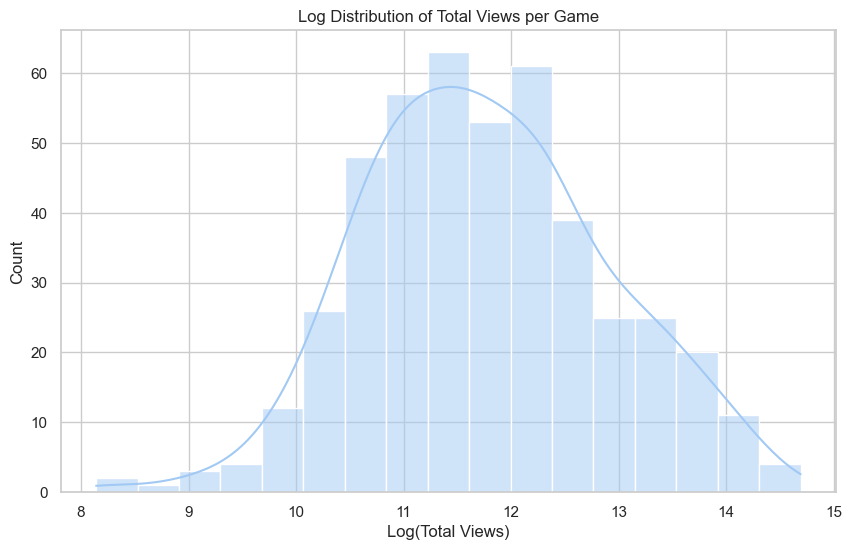

Correlation (Total Views vs Nb Videos): 0.3737
Number of videos < 1000 views: 0
Percentage of videos to be filtered out: 0.00%


In [30]:
# Let's examine the cumulative views for each game to subsequently define a threshold

# Plotting log of total views per game
total_views_per_game = df_merge.groupby('game_id')['view_count'].sum()

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(total_views_per_game), kde=True)
plt.title("Log Distribution of Total Views per Game")
plt.xlabel("Log(Total Views)")
plt.show()

# Check correlation between number of videos and total views
nb_urls_per_game = df_urls.groupby('game_id')['video_id'].count()
df_corr = pd.concat([total_views_per_game, nb_urls_per_game], axis=1)
df_corr.columns = ['total_views', 'nb_urls']

correlation = df_corr.corr().loc['total_views', 'nb_urls']
print(f"Correlation (Total Views vs Nb Videos): {correlation:.4f}")

low_views_count = df_merge[df_merge['view_count'] < 1000].shape[0]
print(f"Number of videos < 1000 views: {low_views_count}")
print(f"Percentage of videos to be filtered out: {low_views_count / df_merge.shape[0]:.2%}")

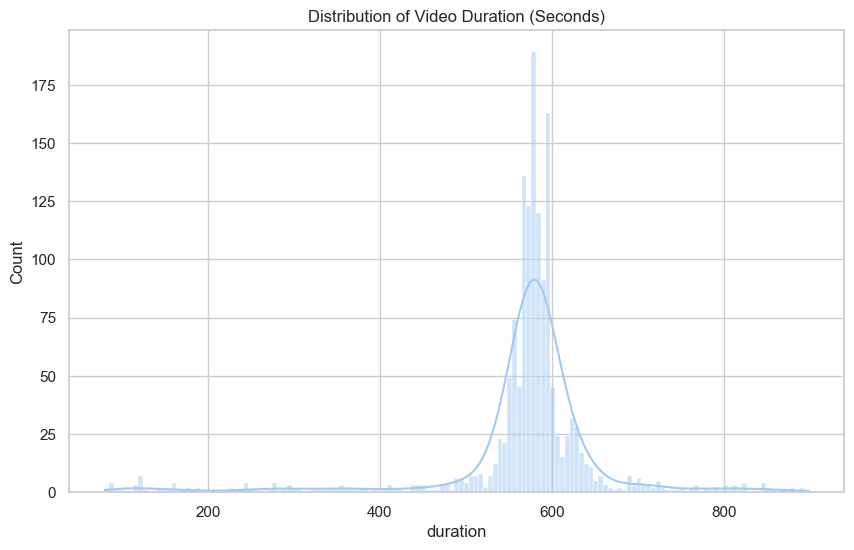

Shortest videos (Top 10):


,url,duration,view_count
980,https://www.youtube.com/watch?v=kUSfZccR5R8,80,19449
1230,https://www.youtube.com/watch?v=fg_LxSqTEwc,84,14217
1399,https://www.youtube.com/watch?v=_DcsuHk2WjI,90,17657
106,https://www.youtube.com/watch?v=uWIXNPxMrIM,90,26542
84,https://www.youtube.com/watch?v=O0r_GD_9-9g,90,40543
919,https://www.youtube.com/watch?v=9ChC_FVI38o,91,7600
1326,https://www.youtube.com/watch?v=x9TBpuxKS3c,96,17745
1500,https://www.youtube.com/watch?v=SJOsPDFzPGQ,99,15751
693,https://www.youtube.com/watch?v=60igGNn2kE8,115,2029
1297,https://www.youtube.com/watch?v=4kbJ3O9po2U,118,17124


In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(x='duration', data=df_merge, kde=True)
plt.title("Distribution of Video Duration (Seconds)")
plt.show()

# The majority are around 9 minutes (540s), which matches standard YouTube highlights.
# The filter fixed in the collection code prevents excessively long videos (often full gameplay or 2K simulations).

# However, very short videos deserve a look:
print("Shortest videos (Top 10):")
display(df_merge.sort_values(by='duration')[['url', 'duration', 'view_count']].head(10))

# These videos are valid, but often of poor quality (portrait mode, flickering).
# Their view counts are generally very low, so they will likely be removed by the 1000-view filter defined above.

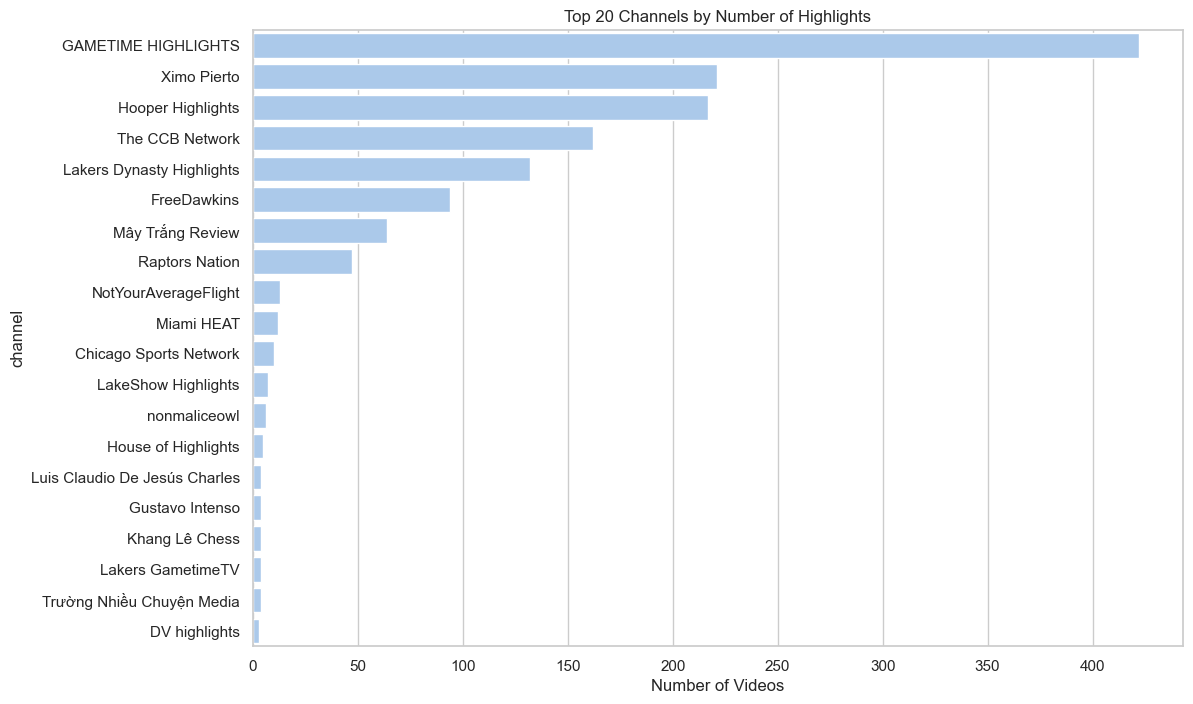

channel
GAMETIME HIGHLIGHTS          422
Ximo Pierto                  221
Hooper Highlights            217
The CCB Network              162
Lakers Dynasty Highlights    132
FreeDawkins                   94
Mây Trắng Review              64
Raptors Nation                47
NotYourAverageFlight          13
Miami HEAT                    12
Name: game_id, dtype: int64


In [32]:
# Count videos per channel
video_per_channel = df_merge.groupby('channel')["game_id"].count().sort_values(ascending=False)

# Display Top 20 Channels
plt.figure(figsize=(12, 8))
sns.barplot(y=video_per_channel.index[:20], x=video_per_channel.values[:20])
plt.title("Top 20 Channels by Number of Highlights")
plt.xlabel("Number of Videos")
plt.show()

# Display full stats
print(video_per_channel.head(10))

# There are a few dominant channels that provide the bulk of the content.